In [25]:
import pandas as pd
import seaborn as sns

In [26]:
sns.load_dataset("tips")

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [27]:
df = pd.read_csv("tips.csv")

In [28]:
df.head()

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4


In [29]:
df.drop(columns="Unnamed: 0", inplace=True)

In [30]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [31]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

<Axes: ylabel='total_bill'>

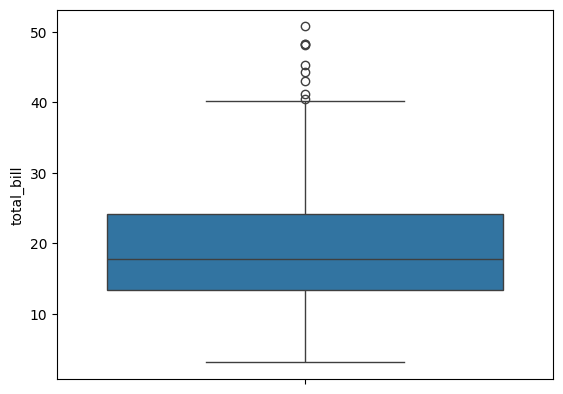

In [32]:
sns.boxplot(df["total_bill"])

In [33]:
q1 = df.describe()["total_bill"]["25%"]
q3 = df.describe()["total_bill"]["75%"]
iqr = q3 - q1

In [34]:
lower_limit = q1 - 1.5 * iqr
upper_limit = q1 + 1.5 * iqr

In [35]:
df["total_bill"].clip(lower_limit, upper_limit, inplace=True)

C:\Users\Akshitha\AppData\Local\Temp\ipykernel_16620\1812915643.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["total_bill"].clip(lower_limit, upper_limit, inplace=True)


In [36]:
d1 = {"Yes":0, "No":1}
df["smoker"] = df["smoker"].map(d1)

In [37]:
d2 = {"Male":0, "Female":1}
df["sex"] = df["sex"].map(d2)

In [38]:
d3 = {"Lunch":0, "Dinner":1}
df["time"] = df["time"].map(d3)

In [39]:
d4 = {"Thur":0, "Fri":1, "Sat":2, "Sun":3}
df["day"] = df["day"].map(d4)

In [40]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,1,1,3,1,2
1,10.34,1.66,0,1,3,1,3
2,21.01,3.50,0,1,3,1,3
3,23.68,3.31,0,1,3,1,2
4,24.59,3.61,1,1,3,1,4


In [41]:
x = df.drop(columns="tip")
y = df["tip"]

In [42]:
x.head()

,total_bill,sex,smoker,day,time,size
0,16.99,1,1,3,1,2
1,10.34,0,1,3,1,3
2,21.01,0,1,3,1,3
3,23.68,0,1,3,1,2
4,24.59,1,1,3,1,4


In [43]:
y.head()

0    1.01
1    1.66
2    3.50
3    3.31
4    3.61
Name: tip, dtype: float64

In [44]:
# Split the data

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=0)

In [45]:
# Model training

from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [46]:
lr.fit(x_train, y_train)

LinearRegression()

In [47]:
# Prediction

y_pred = lr.predict(x_test)

In [50]:
# Evalution

from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)

In [61]:
mse

np.float64(0.9729375031846678)

In [52]:
import numpy as np

In [53]:
rmse = np.sqrt(mse)

In [54]:
rmse

np.float64(0.9863759441433412)

In [55]:
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor

In [58]:
y_pred1 = lr.predict(x_test)

In [59]:
mse = mean_squared_error(y_test,y_pred1)

In [60]:
mse

np.float64(0.9729375031846678)

In [62]:
rmse = np.sqrt(mse)

In [63]:
rmse

np.float64(0.9863759441433412)

In [64]:
import joblib
joblib.dump(lr, "tips1.pkl")

['tips1.pkl']

In [65]:
%%capture
pip install streamlit

In [66]:
%%capture
pip install joblib